In [1]:
from src.Elements import Elements
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X_regression_20250509_192144.npy")
y = np.load("data/training_data/artificial/y_regression_20250509_192151.npy")
y /= 4096
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 160)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 160)

def get_dataloaders(batch_size=128):
    return EvaluationUtils.create_dataloader(X_train, y_train, device, batch_size), EvaluationUtils.create_dataloader(X_test, y_test, device, batch_size)
print(y[2])


[0.         0.         0.         0.02851348 0.         0.
 0.         0.         0.         0.         0.0230036  0.
 0.05140903 0.         0.         0.         0.2305369 ]


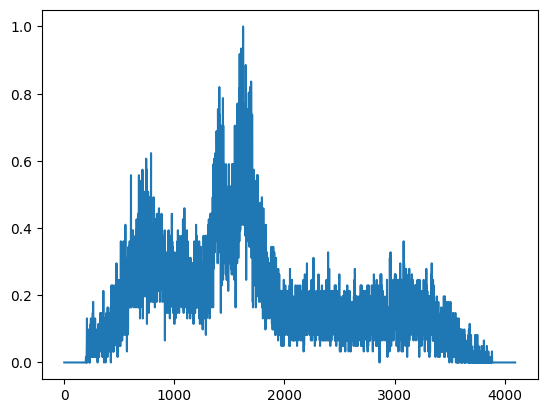

In [3]:
import matplotlib.pyplot as plt 

plt.plot(X[60])

In [4]:
# from pathlib import Path
# from datetime import datetime 
# from src.models import create_model

# for model in ["vit", "lt_vit", "cnn_vit", "resnet1d", "xrfnet"]:
#     model = create_model(model_name=model, device=device)
#     now = datetime.now()
#     dt_string = now.strftime("%d_%m_%Y_%H_%M_%S")
#     path = Path(f"results/{model}/{dt_string}")
#     path.mkdir(parents=True, exist_ok=True)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.MSELoss()
# results = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=50, mode="regression", patience=5)


In [5]:
# def plot_metrics(results, mode="supervised"):
#     """
#     Plots the training and validation loss history and evaluation metrics history.

#     Args:
#         results (dict): The dictionary returned by the train function.
#         mode (str): The training mode used ("supervised", "autoencoder", "constrained_autoencoder", "regression").
#     """
#     train_loss_history = results.get('train_loss_history', [])
#     valid_loss_history = results.get('valid_loss_history', [])
#     metric_histories = results.get('metric_histories', {})

#     epochs = range(1, len(train_loss_history) + 1)

#     # Plot Loss History
#     plt.figure(figsize=(10, 6))
#     plt.plot(epochs, train_loss_history, label='Training Loss')
#     plt.plot(epochs, valid_loss_history, label='Validation Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.title('Training and Validation Loss History')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

#     # Plot Metric Histories based on mode
#     if mode in ["supervised", "constrained_autoencoder"]:
#         plt.figure(figsize=(12, 8))
#         num_metrics = len(metric_histories)
#         # Determine grid size for subplots
#         n_cols = 2
#         n_rows = (num_metrics + n_cols - 1) // n_cols

#         for i, (metric_name, history) in enumerate(metric_histories.items()):
#             plt.subplot(n_rows, n_cols, i + 1)
#             plt.plot(epochs, history)
#             plt.xlabel('Epoch')
#             plt.ylabel(metric_name.replace('_', ' ').title()) # Format metric name nicely
#             plt.title(f'{metric_name.replace("_", " ").title()} History')
#             plt.grid(True)

#         plt.tight_layout()
#         plt.show()

#     elif mode == "regression":
#         plt.figure(figsize=(12, 4))
#         num_metrics = len(metric_histories)
#         # Determine grid size for subplots
#         n_cols = 3 # MSE, MAE, R2
#         n_rows = (num_metrics + n_cols - 1) // n_cols # Should be 1 row

#         for i, (metric_name, history) in enumerate(metric_histories.items()):
#             plt.subplot(n_rows, n_cols, i + 1)
#             plt.plot(epochs, history)
#             plt.xlabel('Epoch')
#             plt.ylabel(metric_name.upper().replace('_', ' ')) # Keep regression metrics uppercase
#             plt.title(f'{metric_name.upper().replace("_", " ")} History')
#             plt.grid(True)

#         plt.tight_layout()
#         plt.show()

#     elif mode == "autoencoder":
#         print.info("No additional metrics to plot for autoencoder mode beyond loss.")


# plot_metrics(results, mode="regression")

In [6]:
# MODEL_NAME = model.__class__.__name__
# torch.save(model.state_dict(), Path(f"data/model_weights/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}"))

In [7]:
import wandb 
import optuna
import time 
import torch.optim as optim
import torch.nn as nn
from src.models import create_model
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional, Callable, Tuple
from contextlib import contextmanager
import traceback
import functools
import os

@dataclass(frozen=True)
class ExperimentConfig:
    project_name: str = "XRFRegression"
    study_name_fmt: str = "{model_name}-regression-study"
    n_trials: int = 150
    epochs: int = 50
    patience: int = 5
    num_outputs: int = 17
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    models_dir: str = "data/model_weights/regression"
    input_seq_len: int = 4096
    models: Tuple[str] = ("resnet1d",)
    output_activations: Tuple[str] = ("none", "sigmoid", "softplus", "tanh_relu")
    batch_size_choices: Tuple[int] = (128,)


def save_model(
    model: torch.nn.Module,
    best_weights: Any,
    cfg: ExperimentConfig,
    model_name: str,
    trial: optuna.Trial,
    run: wandb.sdk.wandb_run.Run
) -> None:
    """
    Load best_weights into `model`, trace (or script) it, save to disk under
    cfg.models_dir/model_name/trial_{n}.pt, and log as a W&B artifact.
    """
    try:
        # Load best weights & eval mode
        model.load_state_dict(best_weights)
        model.eval()

        save_dir = os.path.join(cfg.models_dir, model_name)
        os.makedirs(save_dir, exist_ok=True)
        filename = f"trial_{model_name}_{trial.number}.pt"
        path = os.path.join(save_dir, filename)

        try:
            torch.save(model, path)
        except RuntimeError as trace_err:
            run.log({"torch_save_err": str(trace_err)})


    except Exception as e:
        err_msg = f"JIT logging failed for trial {trial.number}: {e}"
        print(err_msg)
        traceback.print_exc()
        if run:
            run.log({
                "jit_error": str(e),
                "jit_traceback": traceback.format_exc()
            })

def get_activation(name: str) -> nn.Module:
    return {
        "sigmoid": nn.Sigmoid(),
        "tanh_relu": nn.Sequential(nn.Tanh(), nn.ReLU()),
        "softplus": nn.Softplus(threshold=1),
        "none": nn.Identity(),
    }[name]


def build_model(trial: optuna.Trial, model_name: str, cfg: ExperimentConfig) -> Tuple[nn.Module, Dict]:
    if model_name == "vit":
        embed = trial.suggest_int("embed_dim", 128, 512, step=64)
        num_heads = trial.suggest_categorical("num_heads", [4, 6, 8, 12, 16])

        if embed % num_heads != 0:
            raise optuna.TrialPruned()

        hps = {
            "patch_size": trial.suggest_categorical("patch_size", [64, 128, 256, 512, 1024]),
            "embed_dim": embed,
            "hidden_dim": embed * 4,
            "num_heads": num_heads,
            "num_layers": trial.suggest_int("num_layers", 6, 12),
            "dropout_rate": trial.suggest_float("dropout", 0.0, 0.5, step=0.1),
            "num_outputs": cfg.num_outputs,
        }

        base = create_model("vit", **hps)
    if model_name == "lt_vit":
        embed = trial.suggest_int("embed_dim", 128, 384, step=64)
        num_heads = trial.suggest_categorical("num_heads", [4, 6, 8, 12, 16])

        if embed % num_heads != 0:
            raise optuna.TrialPruned()

        num_layers = trial.suggest_int("num_layers", 6, 16)
        num_lt_layers =  trial.suggest_int("num_lt_layers", 1, 5)

        hps = {
            "patch_size": trial.suggest_categorical("patch_size", [64, 128, 256, 512, 1024]),
            "num_layers": num_layers,
            "num_lt_layers": num_lt_layers,
            "embed_dim": embed,
            "hidden_dim": embed * 4,
            "num_heads": num_heads,
            "dropout_rate": trial.suggest_float("dropout", 0, 0.1, step=0.1),
            "num_outputs": cfg.num_outputs,
        }

        base = create_model("lt_vit", **hps)
    elif model_name == "cnn_vit":
        num_heads = trial.suggest_categorical("num_heads", [4, 8, 16])

        hps = {
            "num_patches": trial.suggest_int("num_patches", 16, 128, step=16),
            "num_heads": num_heads,
            "num_layers": trial.suggest_int("num_layers", 6, 12),
            "dropout_rate": trial.suggest_float("dropout", 0.0, 0.5, step=0.1),
            "num_outputs": cfg.num_outputs,
            "overlapping_conv": trial.suggest_categorical("overlapping_conv", [True, False]),
            "use_gelu": trial.suggest_categorical("use_gelu", [True, False])
        }
        base = create_model("cnn_vit", **hps)
    elif model_name == "xrfnet":

        hps = {
            "num_outputs": 17,
        }
        base = create_model("xrfnet", **hps)
    elif model_name == "resnet1d":

        hps = {
            "num_outputs": 17,
        }
        base = create_model("resnet1d", **hps)
    else:
        raise ValueError(f"Unsupported model {model_name}")

    act = get_activation(trial.suggest_categorical("output_activation", cfg.output_activations))
    return nn.Sequential(base, act), hps


        # wandb.config.update({"optimizer": optimizer.__class__.__name__, "criterion": crit.__class__.__name__}, allow_val_change=True)
        # wandb.config.update(trial.params, allow_val_change=True)


def objective(trial: optuna.Trial, cfg: ExperimentConfig, model_name: str):
    # 1) W&B setup
    run = wandb.init(
        project=cfg.project_name,
        group=model_name,
        name=f"{model_name}-trial-{trial.number}-{int(time.time())}",
        config=trial.params,
        reinit=True,
    )

    try:
        # 2) Data
        train_dl, val_dl = get_dataloaders(trial.suggest_categorical("batch_size", cfg.batch_size_choices))

        # 3) Model
        model, model_hps = build_model(trial, model_name, cfg)
        model.to(cfg.device)
        wandb.config.update(model_hps, allow_val_change=True)

        # 4) Optimizer & loss
        optimizer = optim.Adam(model.parameters(), lr=trial.suggest_float("lr",1e-4,1e-2, log=True))
        crit =  getattr(nn, trial.suggest_categorical("criterion", ["MSELoss"]))()
        wandb.config.update(trial.params, allow_val_change=True)

        # 5) Train & evaluate
        results = EvaluationUtils.train(
            model, train_dl, val_dl, optimizer, crit, 
            epochs=cfg.epochs, patience=cfg.patience, mode="regression", wandb_run=run
        )
        loss = results["best_valid_loss"]
        wandb.summary["best_valid_loss"] = loss

        # 6) Optional JIT
        if cfg.models_dir and results.get("best_model_weights"):
            save_model(model, results["best_model_weights"], cfg, model_name, trial, run)

        return np.max(results["metric_histories"]["r2_score"])

    except optuna.exceptions.TrialPruned:
        run.summary["status"] = "pruned"
        raise
    except Exception as e:
        run.summary["status"] = "failed"
        run.log({"error": str(e), "traceback": traceback.format_exc()})
        return float('inf')
    finally:
        run.finish()


def main():
    cfg = ExperimentConfig()
    for model_name in cfg.models:
        study = optuna.create_study(
            study_name=cfg.study_name_fmt.format(model_name=model_name),
            direction="maximize",
            sampler=optuna.samplers.TPESampler(),
            storage=f"sqlite:///{model_name}.db",
            load_if_exists=True,
        )
        study.optimize(functools.partial(objective, cfg=cfg, model_name=model_name), n_trials=cfg.n_trials)
        print("Best loss:", study.best_value, "Params:", study.best_params)


if __name__ == "__main__":
    main()

[I 2025-05-17 17:56:19,392] Using an existing study with name 'resnet1d-regression-study' instead of creating a new one.
wandb: Currently logged in as: erykzarebski0 (mind-flayers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


2025-05-17 17:56:23,457 - INFO - Starting training process (mode: regression, epochs: 50, patience: 5)
2025-05-17 17:56:23,458 - INFO - --- Epoch 1/50 ---
2025-05-17 17:56:24,133 - INFO -   Batch 10/1758, Loss: 0.0031503
2025-05-17 17:56:24,380 - INFO -   Batch 20/1758, Loss: 0.0030841
2025-05-17 17:56:24,632 - INFO -   Batch 30/1758, Loss: 0.0031014
2025-05-17 17:56:24,880 - INFO -   Batch 40/1758, Loss: 0.0031947
2025-05-17 17:56:25,124 - INFO -   Batch 50/1758, Loss: 0.0035434
2025-05-17 17:56:25,371 - INFO -   Batch 60/1758, Loss: 0.0032868
2025-05-17 17:56:25,618 - INFO -   Batch 70/1758, Loss: 0.0031017
2025-05-17 17:56:25,864 - INFO -   Batch 80/1758, Loss: 0.0031437
2025-05-17 17:56:26,633 - INFO -   Batch 90/1758, Loss: 0.0030970
2025-05-17 17:56:26,876 - INFO -   Batch 100/1758, Loss: 0.0030847
2025-05-17 17:56:27,116 - INFO -   Batch 110/1758, Loss: 0.0030769
2025-05-17 17:56:27,355 - INFO -   Batch 120/1758, Loss: 0.0030121
2025-05-17 17:56:27,595 - INFO -   Batch 130/1758,

val_mae,█▃█▅▇▁▃▅▆
val_mse,▂▅▁▃▄▄█▃▄
val_r2_score,▇▇█▇█▃▁▆▅
best_valid_loss,0.00313
val_mae,0.01612
val_mse,0.00313
val_r2_score,-0.38336


[I 2025-05-17 18:03:16,095] Trial 3 finished with value: -0.3833576440811157 and parameters: {'batch_size': 128, 'output_activation': 'sigmoid', 'lr': 0.003194489832597561, 'criterion': 'MSELoss'}. Best is trial 0 with value: 0.25043216347694397.


2025-05-17 18:03:17,771 - INFO - Starting training process (mode: regression, epochs: 50, patience: 5)
2025-05-17 18:03:17,772 - INFO - --- Epoch 1/50 ---
2025-05-17 18:03:18,228 - INFO -   Batch 10/1758, Loss: 0.0011265
2025-05-17 18:03:18,468 - INFO -   Batch 20/1758, Loss: 0.0006951
2025-05-17 18:03:18,709 - INFO -   Batch 30/1758, Loss: 0.0006760
2025-05-17 18:03:18,948 - INFO -   Batch 40/1758, Loss: 0.0006217
2025-05-17 18:03:19,187 - INFO -   Batch 50/1758, Loss: 0.0007807
2025-05-17 18:03:19,426 - INFO -   Batch 60/1758, Loss: 0.0006737
2025-05-17 18:03:19,671 - INFO -   Batch 70/1758, Loss: 0.0005477
2025-05-17 18:03:19,902 - INFO -   Batch 80/1758, Loss: 0.0005597
2025-05-17 18:03:20,130 - INFO -   Batch 90/1758, Loss: 0.0005399
2025-05-17 18:03:20,359 - INFO -   Batch 100/1758, Loss: 0.0006113
2025-05-17 18:03:20,592 - INFO -   Batch 110/1758, Loss: 0.0004098
2025-05-17 18:03:20,831 - INFO -   Batch 120/1758, Loss: 0.0004686
2025-05-17 18:03:21,063 - INFO -   Batch 130/1758,

...

[I 2025-05-17 20:15:24,797] Trial 26 finished with value: inf and parameters: {'batch_size': 128}. Best is trial 8 with value: inf.


error,CUDA error: unknown ...
status,failed
traceback,Traceback (most rece...


[I 2025-05-17 20:15:26,980] Trial 27 finished with value: inf and parameters: {'batch_size': 128}. Best is trial 8 with value: inf.


wandb: ERROR Control-C detected -- Run data was not synced
[W 2025-05-17 20:15:28,769] Trial 28 failed with parameters: {'batch_size': 128} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_37793/4083156298.py", line 200, in objective
    run.finish()
  File "/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/wandb/sdk/wandb_run.py", line 406, in wrapper
    return func(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/wandb/sdk/wandb_run.py", line 503, in wrapper
    return func(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/wandb/sdk/wandb_run.py", li

KeyboardInterrupt: 